# Prelúdio
Definições importantes

In [2]:
from collections import Counter
import matplotlib.pyplot as plt

CUSTOM_ALFABETO = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "U",
    "V",
    "W",
    "X",
    "Y",
    "Z",
    "a",
    "b",
    "c",
    "d",
    "e",
    "f",
    "g",
    "h",
    "i",
    "j",
    "k",
    "l",
    "m",
    "n",
    "o",
    "p",
    "q",
    "r",
    "s",
    "t",
    "u",
    "v",
    "w",
    "x",
    "y",
    "z",
    "Á",
    "À",
    "Â",
    "Ã",
    "Ä",
    "É",
    "È",
    "Ê",
    "Ë",
    "Í",
    "Ì",
    "Î",
    "Ï",
    "Ó",
    "Ò",
    "Ô",
    "Õ",
    "Ö",
    "Ú",
    "Ù",
    "Û",
    "Ü",
    "Ç",
    "á",
    "à",
    "â",
    "ã",
    "ä",
    "é",
    "è",
    "ê",
    "ë",
    "í",
    "ì",
    "î",
    "ï",
    "ó",
    "ò",
    "ô",
    "õ",
    "ö",
    "ú",
    "ù",
    "û",
    "ü",
    "ç",
]

class VigenereCipher:
    def __init__(self, alphabet: list[str] | str):
        if not alphabet:
            raise ValueError("Alphabet cannot be empty.")
        if len(set(alphabet)) != len(alphabet):
            raise ValueError("Alphabet contains duplicate characters.")

        self.alphabet = list(alphabet)
        self._alphabet_set = set(self.alphabet)
        self.alphabet_size = len(self.alphabet)

    def encrypt(self, plaintext: str, key: str, strict: bool = False) -> str:
        """Encrypts text. strict=True raises ValueError on unknown characters."""
        return self._process(plaintext, key, direction=1, strict=strict)

    def decrypt(self, ciphertext: str, key: str, strict: bool = False) -> str:
        """Decrypts text. strict=True raises ValueError on unknown characters."""
        return self._process(ciphertext, key, direction=-1, strict=strict)

    def _process(self, text: str, key: str, direction: int, strict: bool) -> str:
        if not text or not key:
            raise ValueError("Text and key must not be empty.")

        # Sanitize key: drop characters not in the alphabet
        valid_key = [c for c in key if c in self._alphabet_set]
        if not valid_key:
            raise ValueError("Key contains no valid alphabet characters.")

        key_len = len(valid_key)
        key_idx = 0
        result = []

        for char in text:
            if char in self._alphabet_set:
                p_num = self.alphabet.index(char)
                k_num = self.alphabet.index(valid_key[key_idx % key_len])

                # Apply shift
                c_num = (p_num + (direction * k_num)) % self.alphabet_size
                result.append(self.alphabet[c_num])

                # Advance key ONLY when a valid character is processed
                key_idx += 1
            else:
                if strict:
                    raise ValueError(f"Character '{char}' not in defined alphabet.")
                # Pass through ignored characters
                result.append(char)

        return "".join(result)


cipher = VigenereCipher(CUSTOM_ALFABETO)

## Cracking

In [3]:
def ioc(s: str, normalized: bool = True) -> float:
    n = len(s)
    if n <= 1.0: return 0.0
    fs: dict[str, int] = Counter(s)
    sum_of_matches = sum(count * (count - 1) for count in fs.values())
    if not normalized:
        return sum_of_matches / (n * (n - 1))
    return sum_of_matches / ((n * (n - 1)) / len(CUSTOM_ALFABETO))

def score_text(text: str, lang: str = 'pt') -> float:
    # Frequências otimizadas
    freqs_pt = {
        "a": 12.21, "b": 1.01, "c": 3.35, "d": 4.21, "e": 13.19, "f": 1.07,
        "g": 1.08, "h": 1.22, "i": 5.49, "j": 0.30, "k": 0.13, "l": 3.00,
        "m": 5.07, "n": 5.02, "o": 10.22, "p": 3.01, "q": 1.10, "r": 6.73,
        "s": 7.35, "t": 5.07, "u": 4.46, "v": 1.72, "w": 0.05, "x": 0.28,
        "y": 0.04, "z": 0.45, "ã": 0.83, "á": 0.41, "ç": 0.40, "é": 0.52,
    }
    freqs_en = {
        "a": 8.17, "b": 1.49, "c": 2.78, "d": 4.25, "e": 12.70, "f": 2.23,
        "g": 2.02, "h": 6.09, "i": 6.97, "j": 0.15, "k": 0.77, "l": 4.03,
        "m": 2.41, "n": 6.75, "o": 7.51, "p": 1.93, "q": 0.10, "r": 5.99,
        "s": 6.33, "t": 9.06, "u": 2.76, "v": 0.98, "w": 2.36, "x": 0.15,
        "y": 1.97, "z": 0.07,
    }
    target_freqs = freqs_pt if lang == 'pt' else freqs_en
    return sum(target_freqs.get(char.lower(), 0.0) for char in text)

def crack(ct: str, key_length: int, lang: str = 'pt', quiet: bool = False) -> str:
    iterations = 0
    filtered_ct = [c for c in ct if c in cipher.alphabet]
    columns = ["" for _ in range(key_length)]
    
    for i, char in enumerate(filtered_ct):
        columns[i % key_length] += char

    primary_key_guess = ""
    for col in columns:
        best_char, best_score = "", -1.0
        for possible_key_char in cipher.alphabet:
            iterations += 1
            score = score_text(cipher.decrypt(col, possible_key_char), lang)
            if score > best_score:
                best_score = score
                best_char = possible_key_char
        primary_key_guess += best_char
        
    if not quiet:
        print(f"Crack finalizado em {iterations} iterações (Idioma: {lang.upper()})")
    return primary_key_guess

## Plotagem e relatório

In [4]:
def plot_ioc(ct: str, max_len: int = 20, true_key_len: int = None):
    filtered_ct = [c for c in ct if c in cipher.alphabet]
    iocs = []
    
    for length in range(1, max_len + 1):
        columns = ["" for _ in range(length)]
        for i, char in enumerate(filtered_ct):
            columns[i % length] += char
        avg_ioc = sum(ioc(col) for col in columns) / length
        iocs.append((length, avg_ioc))

    baseline = sum(ic for _, ic in iocs) / len(iocs)
    threshold = baseline * 1.5

    plt.figure(figsize=(10, 4))
    lengths, vals = [x[0] for x in iocs], [x[1] for x in iocs]

    plt.plot(lengths, vals, marker='o', linestyle='-', color='#1f77b4', label='IoC Médio')
    plt.axhline(y=threshold, color='#d62728', linestyle='--', label='Threshold (1.5x)')

    for l, ic in iocs:
        if ic > threshold:
            plt.plot(l, ic, marker='o', color='#d62728', markersize=8)

    plt.xticks(lengths)
    plt.xlabel('Tamanho da Chave Candidata')
    plt.ylabel('IoC')
    
    title_str = f'Teste de Friedman (IoC vs Tamanho da Chave)\nTamanho Msg: {len(ct)}'
    if true_key_len: title_str += f' | Chave Real: {true_key_len} chars'
    
    plt.title(title_str)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_degradation(msg: str, key: str, lang: str = 'pt', step: int = 10):
    accuracies = []
    lengths = list(range(step, len(msg) + 1, step))
    key_len = len(key)

    for l in lengths:
        sub_msg = msg[:l]
        sub_ct = cipher.encrypt(sub_msg, key)
        cracked_key = crack(sub_ct, key_len, lang=lang, quiet=True)
        correct_chars = sum(1 for a, b in zip(cracked_key, key) if a == b)
        accuracies.append((correct_chars / key_len) * 100)

    plt.figure(figsize=(10, 4))
    plt.plot(lengths, accuracies, marker='x', linestyle='-', color='#2ca02c')
    plt.axhline(y=100, color='#7f7f7f', linestyle='--', alpha=0.5, label='100% de Acerto')

    plt.xlabel('Tamanho da Mensagem Cifrada (Caracteres)')
    plt.ylabel('Acurácia de Quebra (%)')
    plt.title(f'Performance vs Tamanho da Mensagem\nChave: "{key}" [Tamanho {key_len}] | Idioma: {lang.upper()}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Preparação dos dados

In [5]:
msg = (
    "Acriptografiasemprefoiumaferramentaessencialparaahumanidadedesdeostemposantigos"
    "Odesejodeocultarinformaçõesimportantesimpulsionouodesenvolvimentodecifrascomplexas"
    "Quandoolhamosparaaevoluçãodascomunicaçõespercebemosqueanecessidadedeprivacidadeesegurança"
    "moldouatecnologiamodernaHojeemdiausamosalgoritmosmatemáticosavançadosparaproteger"
    "nossosdadospessoaisegarantirqueasmensagenscheguemapenasaosdestinatárioscorretos"
    "Acomplexidadedoalfabetoeamatemáticaportrásdacodificaçãotornamaanáliseestatística"
    "fascinanteedesafiadora"
)
test_key = "lima"
ciphertext = cipher.encrypt(msg, test_key)

print(f"Texto original ({len(msg)} caracteres):\n{msg[:100]}...\n")
print(f"Texto Cifrado:\n{ciphertext[:100]}...")

Texto original (512 caracteres):
AcriptografiasemprefoiumaferramentaessencialparaahumanidadedesdeostemposantigosOdesejodeocultarinfor...

Texto Cifrado:
lÌèËãäãÈéËÖËÎãÕÏãâÕÉâÕíÏÎÓÕÖéËàÄàäÏÄèãÕÓÓÕÏÎãËèÁÎÔíÏÎÜÛÃÎÎÕÃÔãÔÄâãëÄááãÚÎÜëËÖÇêoÒÏêÄÛÇÔÄâÌíÎêËèËàÓãÖ...


# Testes
## Teste 1 - Análise do Índice de Coincidência

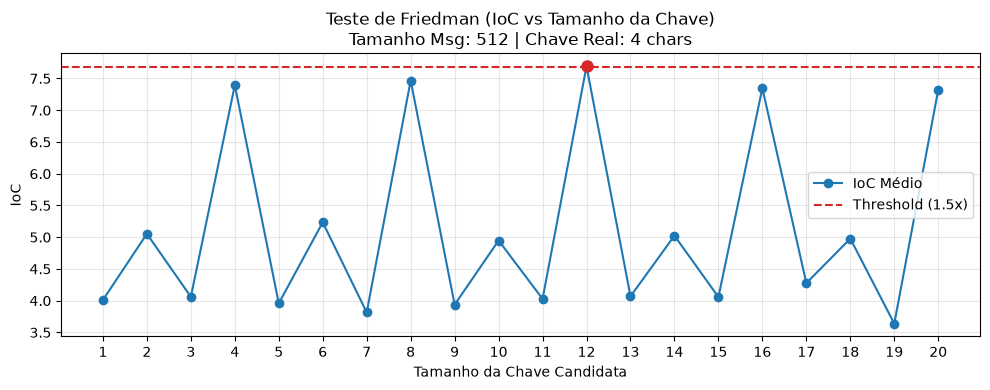

In [6]:
plot_ioc(ciphertext, max_len=20, true_key_len=len(test_key))

## Teste 2 - Gráfico de Degradação
Mensagens curtas resultam em performance pior.

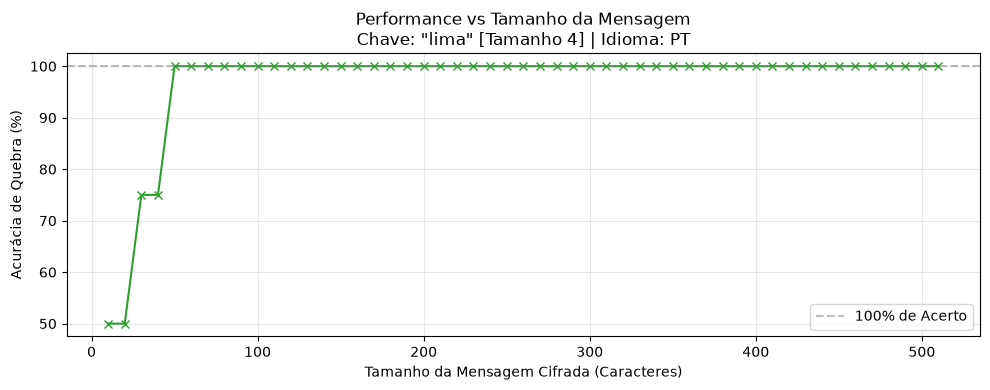

In [7]:
# Você pode brincar alterando o idioma esperado ou modificando a chave neste teste
plot_degradation(msg, test_key, lang='pt', step=10)

## Teste 3 - Validação final

In [8]:
# Passando as informações descobertas pelos gráficos (sabemos que a chave tem tamanho 4)
tamanho_chave_estimado = 4

print(f"Iniciando quebra completa da mensagem assumindo tamanho de chave {tamanho_chave_estimado}...")
cracked_key = crack(ciphertext, key_length=tamanho_chave_estimado, lang='pt')

print("-" * 30)
print(f"Chave real original: {test_key}")
print(f"Chave recuperada pelo script: {cracked_key}")
print(f"Sucesso total? {test_key == cracked_key}")
print("-" * 30)
print(f"Decriptado:\n{cipher.decrypt(ciphertext, cracked_key)[:150]}...")

Iniciando quebra completa da mensagem assumindo tamanho de chave 4...
Crack finalizado em 392 iterações (Idioma: PT)
------------------------------
Chave real original: lima
Chave recuperada pelo script: lima
Sucesso total? True
------------------------------
Decriptado:
AcriptografiasemprefoiumaferramentaessencialparaahumanidadedesdeostemposantigosOdesejodeocultarinformaçõesimportantesimpulsionouodesenvolvimentodecifr...
